In [ ]:
import zarr
import numpy as np
import matplotlib.pyplot as plt

In [3]:
arr = zarr.open('/mnt/Data1/Nick/transcription_pipeline/test_data/NSPARC/2025-09-19/MCP-mSG_His-RFP_RBS(002)(trans-het)_embryo02/collated_dataset/collated_dataset_ch01.zarr', mode='r')

data = np.array(arr)  # loads everything into memory

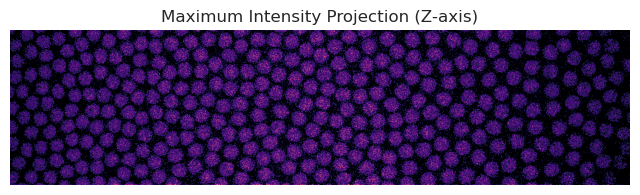

In [7]:
# assuming Z is the first or last axis; adjust `axis` as needed
max_proj = np.max(data, axis=1)

# Plot the maximum intensity projection
plt.figure(figsize=(8, 8))
plt.imshow(max_proj[100, :, :], cmap='magma')
plt.title("Maximum Intensity Projection (Z-axis)")
plt.axis('off')
plt.show()

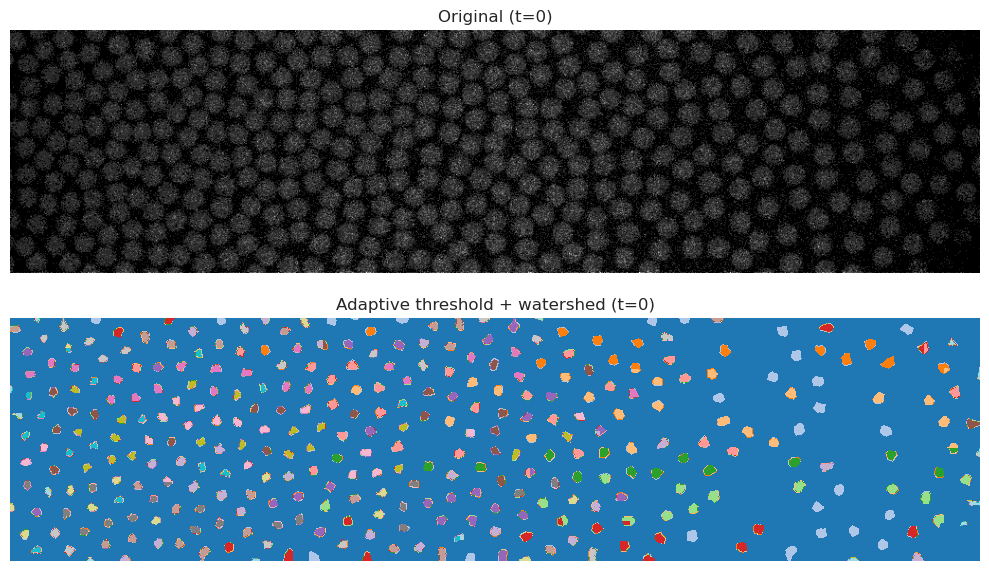

Segmentation complete. Result shape: (399, 256, 1024)


In [44]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, morphology, measure
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.filters import threshold_local
from scipy import ndimage as ndi

# max_proj: (t, y, x)
labeled_masks = []

for i in range(max_proj.shape[0]):
    img = max_proj[i]
    img = (img - img.min()) / (img.max() - img.min())

    # --- Step 1: Smooth to reduce noise ---
    smooth = filters.gaussian(img, sigma=2)

    # --- Step 2: Adaptive/local threshold ---
    block_size = 51  # adjust based on nucleus size
    local_thresh = threshold_local(smooth, block_size, offset=-0.0)
    binary = smooth > local_thresh

    # Erosion
    clean = morphology.binary_erosion(binary, morphology.disk(1))

    # --- Step 3: Morphological cleanup ---
    clean = morphology.remove_small_objects(binary, min_size=50)
    clean = morphology.remove_small_holes(clean, area_threshold=100)

    # Optional: slightly erode to separate touching nuclei
    clean = morphology.binary_erosion(clean, morphology.disk(5))

    # --- Step 4: Distance transform ---
    distance = ndi.distance_transform_edt(clean)

    # --- Step 5: Find local maxima for watershed markers ---
    local_max = peak_local_max(
        distance,
        footprint=np.ones((15, 15)),  # adjust based on expected nucleus spacing
        labels=clean
    )

    # --- Step 6: Create markers ---
    markers = np.zeros_like(clean, dtype=int)
    markers[tuple(local_max.T)] = np.arange(1, len(local_max) + 1)

    # --- Step 7: Watershed segmentation ---
    labels = watershed(-distance, markers, mask=clean)
    labeled_masks.append(labels)

    # --- Optional: visualize one frame ---
    if i == 0:
        fig, axes = plt.subplots(2, 1, figsize=(10, 6))
        ax1, ax2 = axes

        ax1.imshow(img, cmap='gray')
        ax1.set_title('Original (t=0)')
        ax1.axis('off')

        ax2.imshow(labels, cmap='tab20')
        ax2.set_title('Adaptive threshold + watershed (t=0)')
        ax2.axis('off')

        plt.tight_layout()
        plt.show()

labeled_masks = np.array(labeled_masks)
print("Segmentation complete. Result shape:", labeled_masks.shape)
